# Ramani Data Features
So far, we've been working with a relatively complex dataset, consisting of many different immunne cells. To simplify testing, we'll see if we can produce similar results for a dataset with just 4 cell lines. Before performing UOT, it is worth investigating features of this data to determine proper thresholds.

## Imports

In [1]:
### Enabling fast reload ###
%load_ext autoreload
%autoreload 2

In [18]:
### Imports ###
import sys
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, fetch_region, get_cool_name, hic_mask_threshold, bin_contact_map
from hicvisutils import hic_vis_region

In [3]:
### Setting Directories ###
sc_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/ramani_cool_files'
metadata_save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_uot_ramani/Metadata'

## Importing Data

In [4]:
### Importing coolers ###
clrs = import_cool_dir(sc_dir)
resolutions = []
names = []

for clr in clrs:
    names.append(get_cool_name(clr))

    res = clr.binsize
    if res not in resolutions:
        resolutions.append(res)

In [7]:
### Checking resolutions ###
resolutions

[np.int64(1000000)]

We can confirm these files are also at a 1 Mb resolution.

## Checking Chr1 Data

In [8]:
### Extracting chr1 ###
chr1s = []
for clr in clrs:
    chr1s.append(fetch_region(clr, 'chr1'))

In [9]:
### Combining reads into one ###
combined_values = []

rows, cols = np.tril_indices_from(chr1s[0], k=1)

for chr1 in chr1s:
    combined_values.append(chr1[rows, cols])

combined_values = np.concatenate(combined_values)
non_zero = combined_values[combined_values > 0]

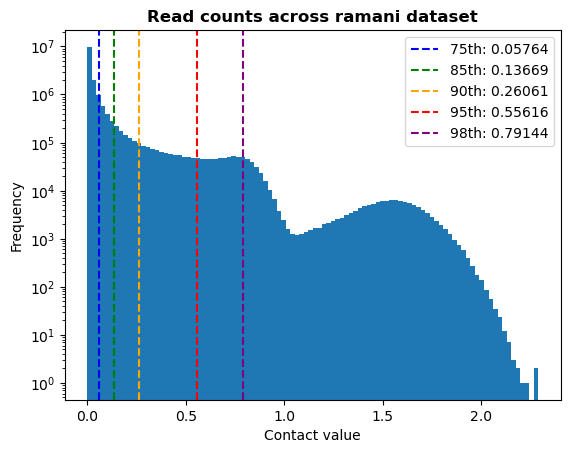

In [10]:
### Plotting ###
    # Calculating percentiles
percentiles = [75, 85, 90, 95, 98]
pvals = np.percentile(non_zero, percentiles)

    # Plotting percentiles
colors = ['blue', 'green', 'orange', 'red', 'purple']
for p, val, c in zip(percentiles, pvals, colors):
    plt.axvline(val, linestyle='--', color=c, label=f'{p}th: {val:.5f}')

    # Plotting histogram
plt.hist(non_zero, log=True, bins=100)
plt.title("Read counts across ramani dataset", fontweight='bold')
plt.xlabel("Contact value")
plt.ylabel("Frequency")
plt.legend()

The data distribution is a bit different from the previous single cell data. A threshold of 95% might be less warranted than before.

## Verifying remaining counts after thresholding

In [11]:
### Thresholding data ###
threshold_data = {}
for p in percentiles:
    comb_vals = []
    for chr1 in chr1s:
        comb_vals.append(hic_mask_threshold(chr1, p, 'percentile')[0])
    threshold_data[p] = comb_vals

In [12]:
### Converting to counts ###
counts_data = {}

for p, data in threshold_data.items():
    totals = [len(values) for values in data]
    counts_data[p] = totals

counts_df = pd.DataFrame(counts_data)
counts_df

,75,85,90,95,98
0,6440,3820,2509,1199,413
1,6428,3812,2503,1196,412
2,6423,3809,2503,1196,412
3,6431,3813,2505,1197,413
4,6440,3819,2508,1198,412
...,...,...,...,...,...
615,6442,3820,2509,1198,412
616,6437,3817,2508,1198,412
617,6439,3818,2507,1198,413
618,6440,3819,2509,1199,413


In [13]:
### Reporting means ###
counts_df.mean(axis=0)

75    6437.435484
85    3817.358065
90    2507.461290
95    1198.272581
98     413.408065
dtype: float64

## Analyzing mass per cell line
To see if using UOT would results in mass biases when applying our method to this data, we'll visualize the remaining mass for both the 95th percentile and 98th percentile per cell line.

### Creating Mass Reference

In [14]:
### Sorting names in natural order ###
def extract_cell_number(name):
    match = re.match(r'cell(\d+)_', name)
    return int(match.group(1))

names = sorted(names, key=extract_cell_number)

In [15]:
### Exporting file to cell line look up to csv ###
lookup = []

for name in names:
    parts = name.split('_')
    cell_line = parts[1]

    lookup.append({
        'cell_name': name,
        'cell_line': cell_line
    })

lookup_df = pd.DataFrame(lookup)
lookup_df.to_csv(f"{sc_dir}/cell_line_mapping.csv", index = False)

In [28]:
### Calculating mass per file ###
cell_names = []
masses_95_1mb = []
masses_98_1mb = []
masses_87_1mb = []
masses_85_2mb = []
masses_85_4mb = []

for clr in clrs:
    cell_name = get_cool_name(clr)
    cell_names.append(cell_name)
    clr_chr1 = fetch_region(clr, 'chr1')

    # 1 mb
    mass_list_95_1mb = hic_mask_threshold(clr_chr1, 95, "percentile", "max")[0]
    mass_list_98_1mb = hic_mask_threshold(clr_chr1, 98, "percentile", "max")[0]
    mass_list_87_1mb = hic_mask_threshold(clr_chr1, 87, "percentile", "max")[0]
    masses_95_1mb.append(mass_list_95_1mb.sum())
    masses_98_1mb.append(mass_list_98_1mb.sum())
    masses_87_1mb.append(mass_list_87_1mb.sum())

    # 2 mb
    clr_chr1_2mb = bin_contact_map(clr_chr1, 2)
    mass_list_85_2mb = hic_mask_threshold(clr_chr1_2mb, 85, "percentile", "max")[0]
    masses_85_2mb.append(mass_list_85_2mb.sum())

    # 4 mb
    clr_chr1_4mb = bin_contact_map(clr_chr1, 4)
    mass_list_85_4mb = hic_mask_threshold(clr_chr1_4mb, 85, "percentile", "max")[0]
    masses_85_4mb.append(mass_list_85_4mb.sum())

In [30]:
### Creating and saving df ###
max_norm_masses = pd.DataFrame({
    'cell_name': cell_names,
    'total_mass_1mb_87': masses_87_1mb,
    'total_mass_1mb_95': masses_95_1mb,
    'total_mass_1mb_98': masses_98_1mb,
    'total_mass_2mb_85': masses_85_2mb,
    'total_mass_4mb_85': masses_85_4mb
})
max_norm_masses = max_norm_masses.merge(lookup_df, on='cell_name')

max_norm_masses.to_csv(f"{metadata_save_dir}/maxnorm_total_mass.csv")

### Visualizing Distribution 95th Percentile

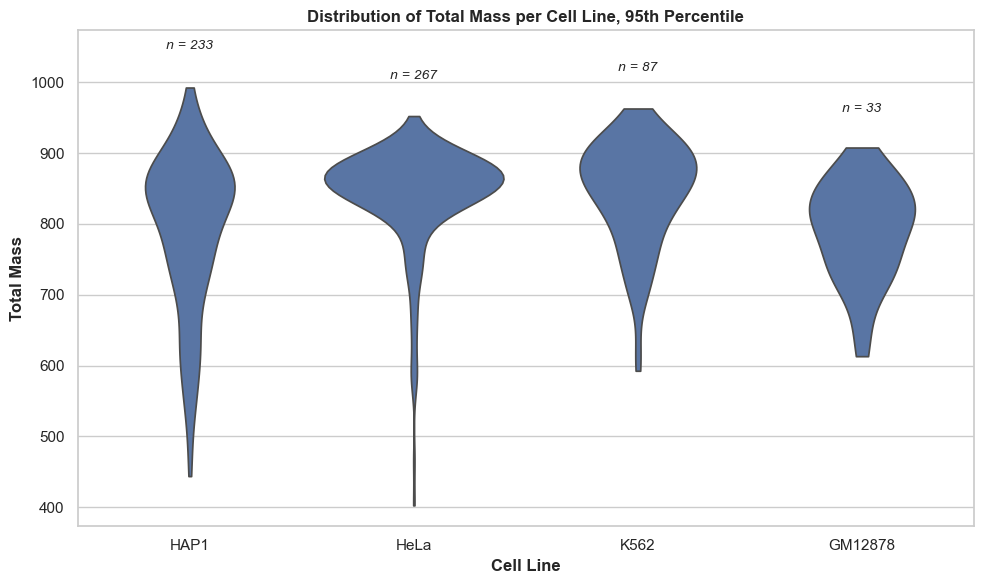

In [21]:
### Violin + swarm plots ###
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plots
    # Violin plot
ax = sns.violinplot(
    data=max_norm_masses,
    x="cell_line",
    y="total_mass_1mb_95",
    inner=None,  
    cut=0
)

# Add cell count annotations
counts = max_norm_masses["cell_line"].value_counts()

    # Y position above max mass
y_max = max_norm_masses.groupby("cell_line")["total_mass_1mb_95"].max()

    # Adding extra space to prevent overlap with title
y_min, y_max_plot = ax.get_ylim()
ax.set_ylim(y_min, y_max_plot * 1.05)

for i, cell_line in enumerate(ax.get_xticklabels()):
    cl = cell_line.get_text()
    ax.text(
        i,
        y_max[cl] * 1.05,
        f"n = {counts[cl]}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontstyle='italic'
    )

# Labels
ax.set_xlabel("Cell Line", fontweight='bold')
ax.set_ylabel("Total Mass", fontweight='bold')
ax.set_title("Distribution of Total Mass per Cell Line, 95th Percentile", fontweight='bold')

plt.tight_layout()

### Visualizing Distribution 98th Percentile

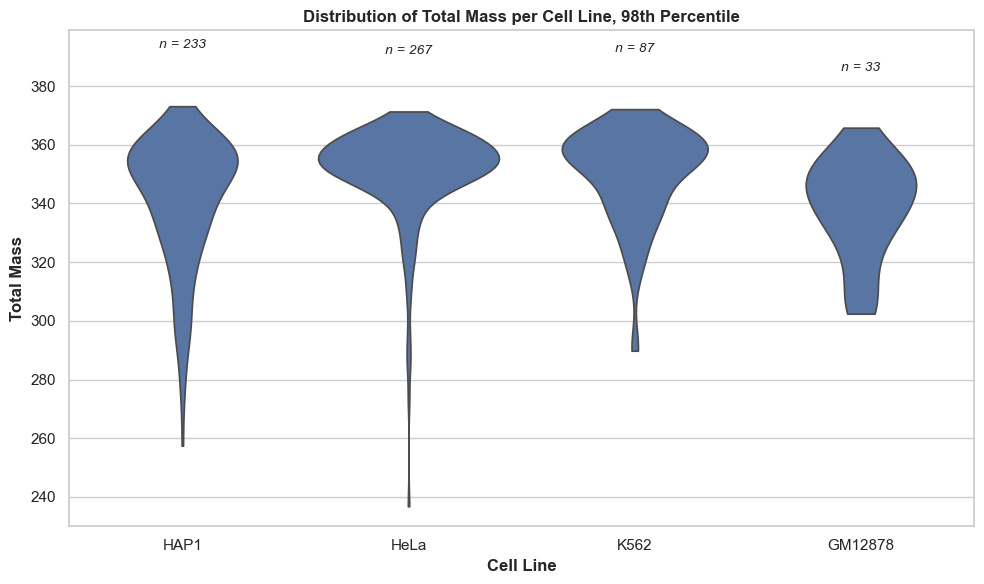

In [22]:
### Violin + swarm plots ###
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plots
    # Violin plot
ax = sns.violinplot(
    data=max_norm_masses,
    x="cell_line",
    y="total_mass_1mb_98",
    inner=None,  
    cut=0
)

# Add cell count annotations
counts = max_norm_masses["cell_line"].value_counts()

    # Y position above max mass
y_max = max_norm_masses.groupby("cell_line")["total_mass_1mb_98"].max()

    # Adding extra space to prevent overlap with title
y_min, y_max_plot = ax.get_ylim()
ax.set_ylim(y_min, y_max_plot * 1.05)

for i, cell_line in enumerate(ax.get_xticklabels()):
    cl = cell_line.get_text()
    ax.text(
        i,
        y_max[cl] * 1.05,
        f"n = {counts[cl]}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontstyle='italic'
    )

# Labels
ax.set_xlabel("Cell Line", fontweight='bold')
ax.set_ylabel("Total Mass", fontweight='bold')
ax.set_title("Distribution of Total Mass per Cell Line, 98th Percentile", fontweight='bold')

plt.tight_layout()

### Visualizing 87th percentile
Testing in a different notebook (ramani_uot_time.ipynb) shows 87th percentile removed is the best my laptop can do. Thus, we'll investigate the data distribution of this percentile.

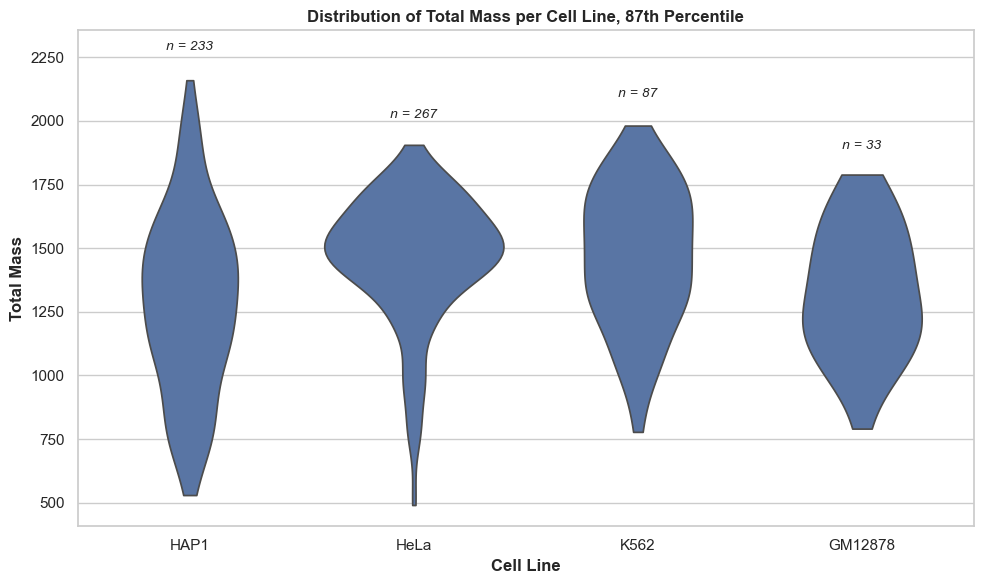

In [33]:
### Violin + swarm plots ###
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plots
    # Violin plot
ax = sns.violinplot(
    data=max_norm_masses,
    x="cell_line",
    y="total_mass_1mb_87",
    inner=None,  
    cut=0
)

# Add cell count annotations
counts = max_norm_masses["cell_line"].value_counts()

    # Y position above max mass
y_max = max_norm_masses.groupby("cell_line")["total_mass_1mb_87"].max()

    # Adding extra space to prevent overlap with title
y_min, y_max_plot = ax.get_ylim()
ax.set_ylim(y_min, y_max_plot * 1.05)

for i, cell_line in enumerate(ax.get_xticklabels()):
    cl = cell_line.get_text()
    ax.text(
        i,
        y_max[cl] * 1.05,
        f"n = {counts[cl]}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontstyle='italic'
    )

# Labels
ax.set_xlabel("Cell Line", fontweight='bold')
ax.set_ylabel("Total Mass", fontweight='bold')
ax.set_title("Distribution of Total Mass per Cell Line, 87th Percentile", fontweight='bold')

plt.tight_layout()

## Visualizing Cells

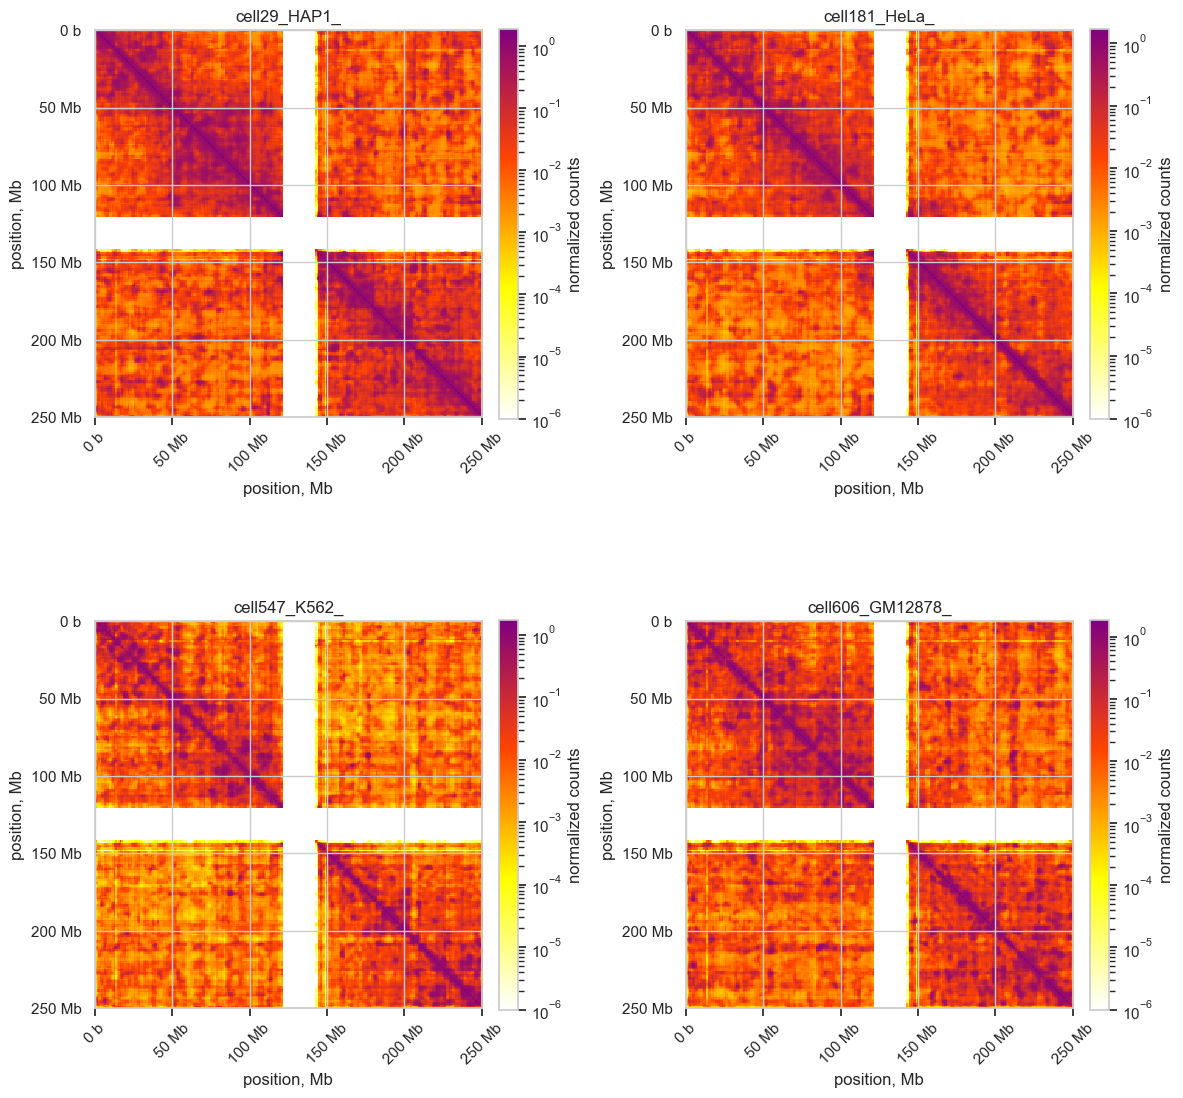

In [95]:
### Visualizing cells from each cell line ###
hap1 = clrs[4]
hela = clrs[6]
k562 = clrs[10]
gm12878 = clrs[193]
display = [hap1, hela, k562, gm12878]

fig, ax = plt.subplots(2, 2, figsize=(12, 12))
axes = ax.flatten()

for i, map in enumerate(display):
    hic_vis_region(map, 'chr1', cmap='higlass', ax=axes[i], title=get_cool_name(map), data_type='normalized')

plt.tight_layout()

## 4 Mb
Analysis after the investigation from above shows that 4 Mb at 85% is comparable to 1 Mb at 87%. Thus, we should repeat the investigations above for this resolution and threshold to verify if this is warranted.

### Visualizing Distribution

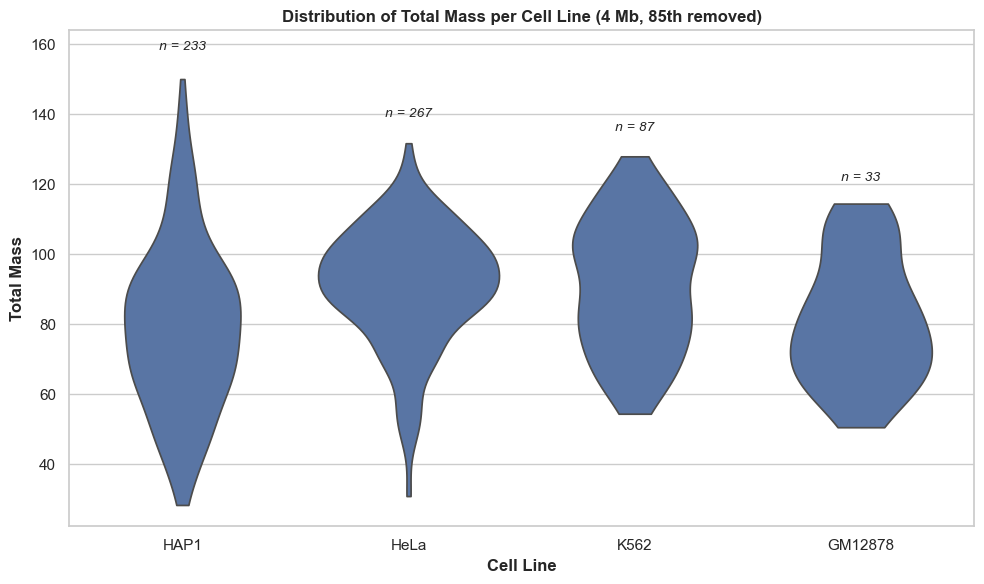

In [31]:
### Violin + swarm plots ###
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plots
    # Violin plot
ax = sns.violinplot(
    data=max_norm_masses,
    x="cell_line",
    y="total_mass_4mb_85",
    inner=None,  
    cut=0
)

# Add cell count annotations
counts = max_norm_masses["cell_line"].value_counts()

    # Y position above max mass
y_max = max_norm_masses.groupby("cell_line")["total_mass_4mb_85"].max()

    # Adding extra space to prevent overlap with title
y_min, y_max_plot = ax.get_ylim()
ax.set_ylim(y_min, y_max_plot * 1.05)

for i, cell_line in enumerate(ax.get_xticklabels()):
    cl = cell_line.get_text()
    ax.text(
        i,
        y_max[cl] * 1.05,
        f"n = {counts[cl]}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontstyle='italic'
    )

# Labels
ax.set_xlabel("Cell Line", fontweight='bold')
ax.set_ylabel("Total Mass", fontweight='bold')
ax.set_title("Distribution of Total Mass per Cell Line (4 Mb, 85th removed)", fontweight='bold')

plt.tight_layout()

The shapes of the distributions are shifted a bit too much in my opinion, maybe making 4 Mb at an 85th percentile threshold not entirely warranted.

## 2 Mb
Due to the results above showing more distortion of the original dataset that desirable, we'll see if the same is ture for a 2 Mb resolution at an 85% threshold.

### Visualizing Distribution

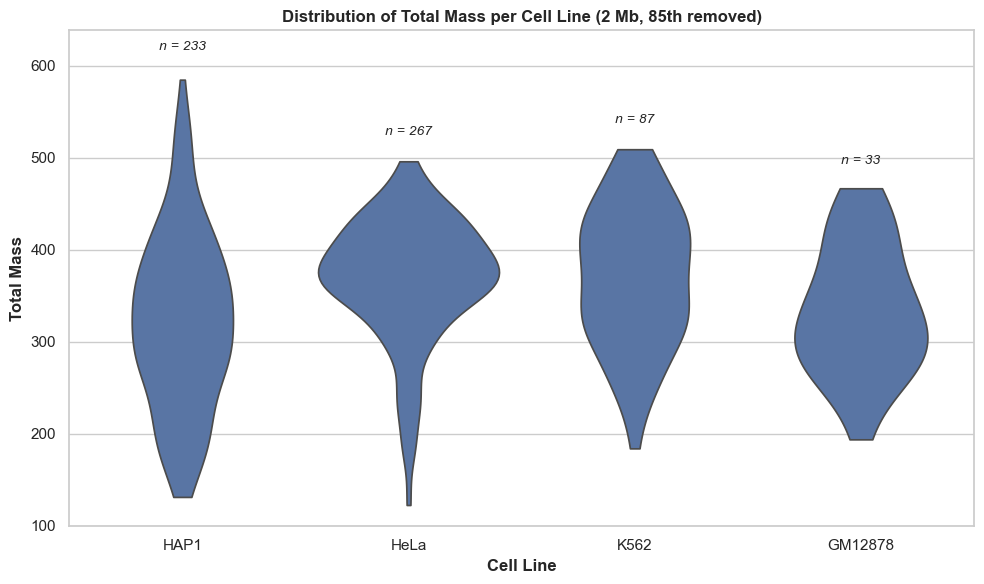

In [32]:
### Violin + swarm plots ###
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plots
    # Violin plot
ax = sns.violinplot(
    data=max_norm_masses,
    x="cell_line",
    y="total_mass_2mb_85",
    inner=None,  
    cut=0
)

# Add cell count annotations
counts = max_norm_masses["cell_line"].value_counts()

    # Y position above max mass
y_max = max_norm_masses.groupby("cell_line")["total_mass_2mb_85"].max()

    # Adding extra space to prevent overlap with title
y_min, y_max_plot = ax.get_ylim()
ax.set_ylim(y_min, y_max_plot * 1.05)

for i, cell_line in enumerate(ax.get_xticklabels()):
    cl = cell_line.get_text()
    ax.text(
        i,
        y_max[cl] * 1.05,
        f"n = {counts[cl]}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontstyle='italic'
    )

# Labels
ax.set_xlabel("Cell Line", fontweight='bold')
ax.set_ylabel("Total Mass", fontweight='bold')
ax.set_title("Distribution of Total Mass per Cell Line (2 Mb, 85th removed)", fontweight='bold')

plt.tight_layout()

Distortion specifically at GM12878 is not as bad as with 4mb, but is that worth the severe increase in computation time?